In [711]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import matplotlib.dates as mdates
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


In [712]:
GDAXI_dta = pd.read_csv("GDAXI.csv").iloc[::-1].reset_index(drop=True)
GSPC_dta = pd.read_csv("GSPC.csv").iloc[::-1].reset_index(drop=True)


In [713]:
GDAXI_dta.info()
GSPC_dta.info()


<class 'pandas.DataFrame'>
RangeIndex: 5330 entries, 0 to 5329
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5330 non-null   str    
 1    Open   5330 non-null   float64
 2    High   5330 non-null   float64
 3    Low    5330 non-null   float64
 4    Close  5330 non-null   float64
dtypes: float64(4), str(1)
memory usage: 250.6 KB
<class 'pandas.DataFrame'>
RangeIndex: 5284 entries, 0 to 5283
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    5284 non-null   str    
 1    Open   5284 non-null   float64
 2    High   5284 non-null   float64
 3    Low    5284 non-null   float64
 4    Close  5284 non-null   float64
dtypes: float64(4), str(1)
memory usage: 248.5 KB


In [714]:
D = pd.DataFrame({
    "Date": pd.to_datetime(GDAXI_dta["Date"], format="%m/%d/%y"),
    "D_Close": GDAXI_dta[" Close"],
})
S = pd.DataFrame({
    "Date": pd.to_datetime(GSPC_dta["Date"], format="%m/%d/%y"),
    "S_Close": GSPC_dta[" Close"],
})

df = pd.merge(D, S, on="Date", how="inner").sort_values("Date").reset_index(drop=True)
df["D_absR"] = (df["D_Close"].diff(1))
df["S_absR"] = (df["S_Close"].diff(1))
df["D_logR"] = np.log(df["D_Close"]).diff(1)
df["S_logR"] = np.log(df["S_Close"]).diff(1)
df["D_pR"] = df["D_Close"].pct_change()*100
df["S_pR"] = df["S_Close"].pct_change()*100

df["D_pSR"] = (df["D_logR"])**2
df["S_pSR"] = (df["S_logR"])**2

df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5194 entries, 0 to 5193
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     5194 non-null   datetime64[us]
 1   D_Close  5194 non-null   float64       
 2   S_Close  5194 non-null   float64       
 3   D_absR   5193 non-null   float64       
 4   S_absR   5193 non-null   float64       
 5   D_logR   5193 non-null   float64       
 6   S_logR   5193 non-null   float64       
 7   D_pR     5193 non-null   float64       
 8   S_pR     5193 non-null   float64       
 9   D_pSR    5193 non-null   float64       
 10  S_pSR    5193 non-null   float64       
dtypes: datetime64[us](1), float64(10)
memory usage: 446.5 KB


In [715]:
df.tail(30)

,Date,D_Close,S_Close,D_absR,S_absR,D_logR,S_logR,D_pR,S_pR,D_pSR,S_pSR
5164,2020-11-16,13138.61,3626.91,61.89,41.76,0.004722,0.011581,0.473284,1.164805,2.229420e-05,1.341134e-04
5165,2020-11-17,13133.47,3609.53,-5.14,-17.38,-0.000391,-0.004803,-0.039121,-0.479196,1.531078e-07,2.307338e-05
5166,2020-11-18,13201.89,3567.79,68.42,-41.74,0.005196,-0.011631,0.520959,-1.156383,2.699912e-05,1.352851e-04
5167,2020-11-19,13086.16,3581.87,-115.73,14.08,-0.008805,0.003939,-0.876617,0.394642,7.752482e-05,1.551299e-05
5168,2020-11-20,13137.25,3557.54,51.09,-24.33,0.003897,-0.006816,0.390412,-0.679254,1.518289e-05,4.645398e-05
5169,2020-11-23,13126.97,3577.59,-10.28,20.05,-0.000783,0.005620,-0.078251,0.563592,6.127979e-07,3.158546e-05
5170,2020-11-24,13292.44,3635.41,165.47,57.82,0.012527,0.016033,1.260535,1.616172,1.569147e-04,2.570413e-04
5171,2020-11-25,13289.80,3629.65,-2.64,-5.76,-0.000199,-0.001586,-0.019861,-0.158442,3.945342e-08,2.514356e-06
5172,2020-11-27,13335.68,3638.35,45.88,8.70,0.003446,0.002394,0.345227,0.239693,1.187716e-05,5.731510e-06
5173,2020-11-30,13291.16,3621.63,-44.52,-16.72,-0.003344,-0.004606,-0.333841,-0.459549,1.118232e-05,2.121599e-05


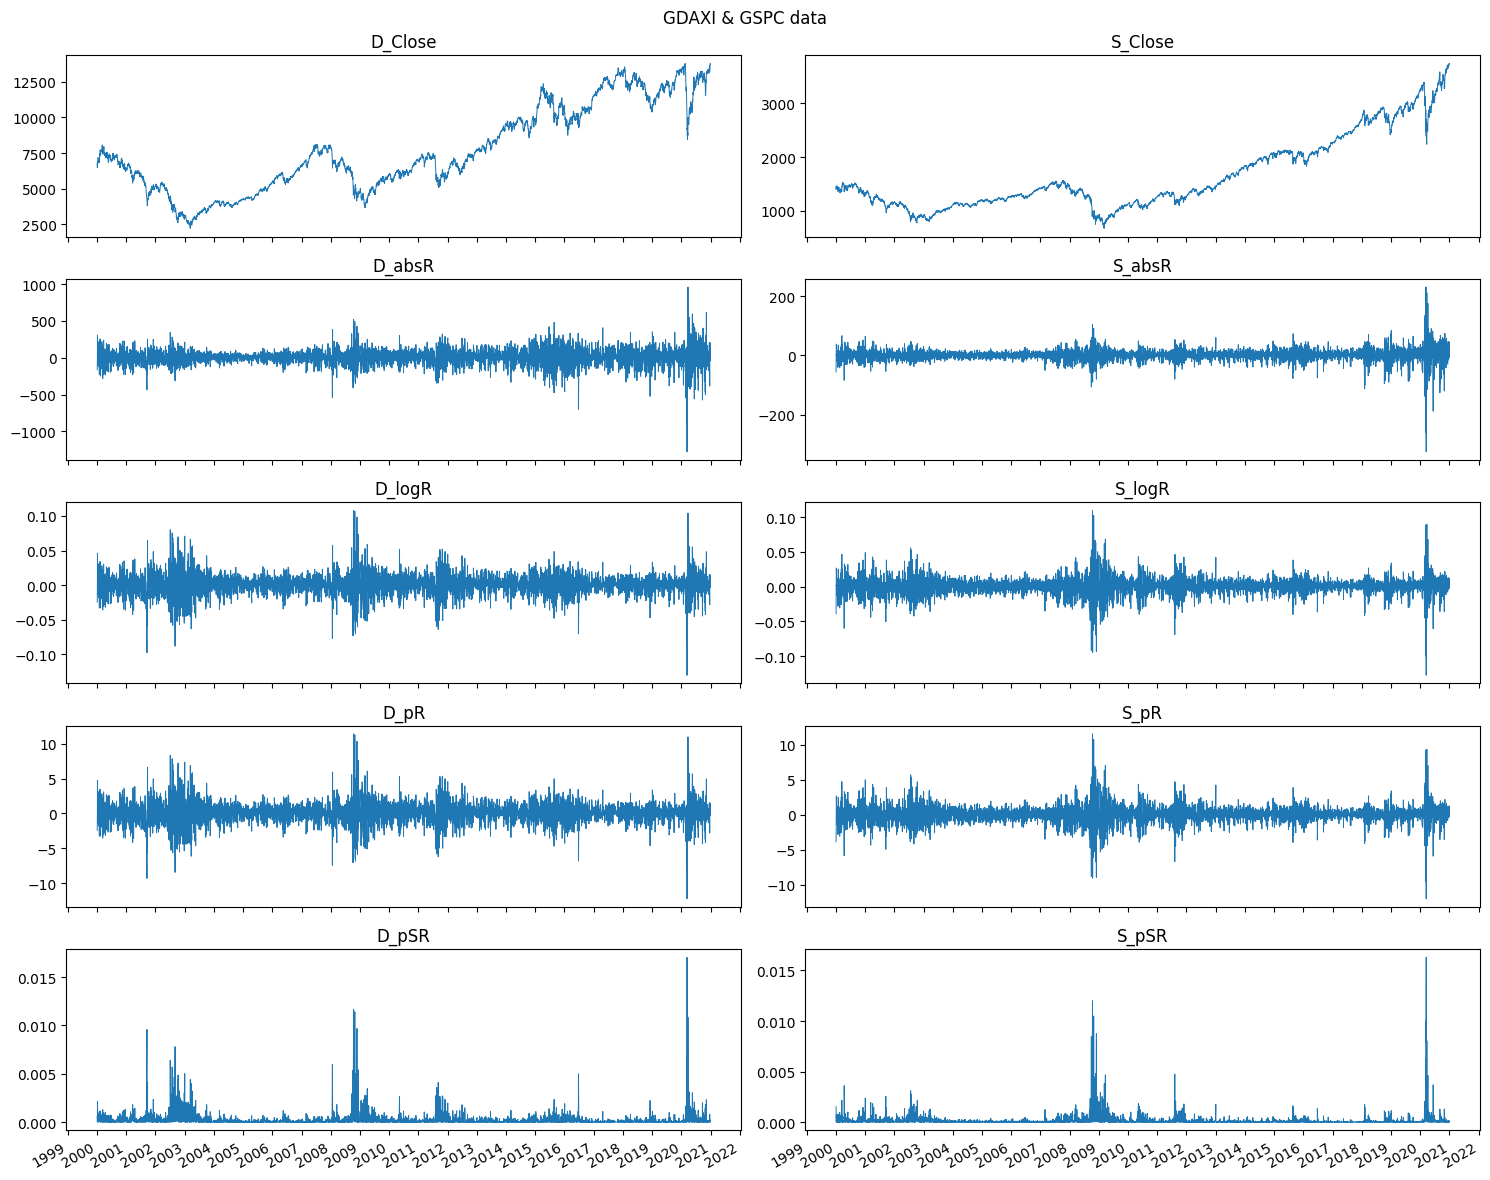

In [716]:

dates = pd.to_datetime(df["Date"], format="%m/%d/%y")
cols = [k for k in df.keys() if k != "Date"]

fig, axes = plt.subplots(5, 2, figsize=(15, 12), sharex=True)
for ax, k in zip(axes.flat, cols):
    ax.plot(dates, df[k], lw=0.7)
    ax.set_title(k)
    ax.xaxis.set_major_locator(mdates.YearLocator(base=1))   # every 3 years
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

for ax in axes.flat[len(cols):]:
    ax.set_visible(False)
fig.autofmt_xdate()
plt.suptitle("GDAXI & GSPC data")
plt.tight_layout()
plt.show()


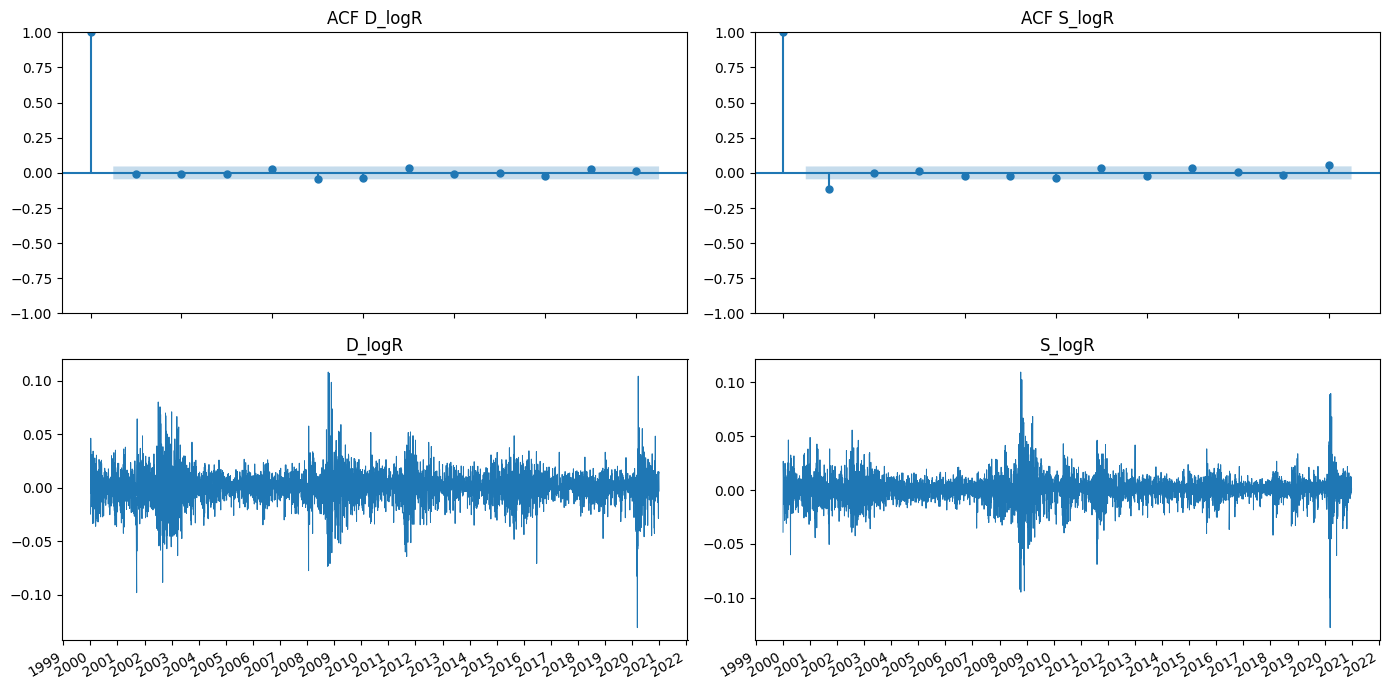

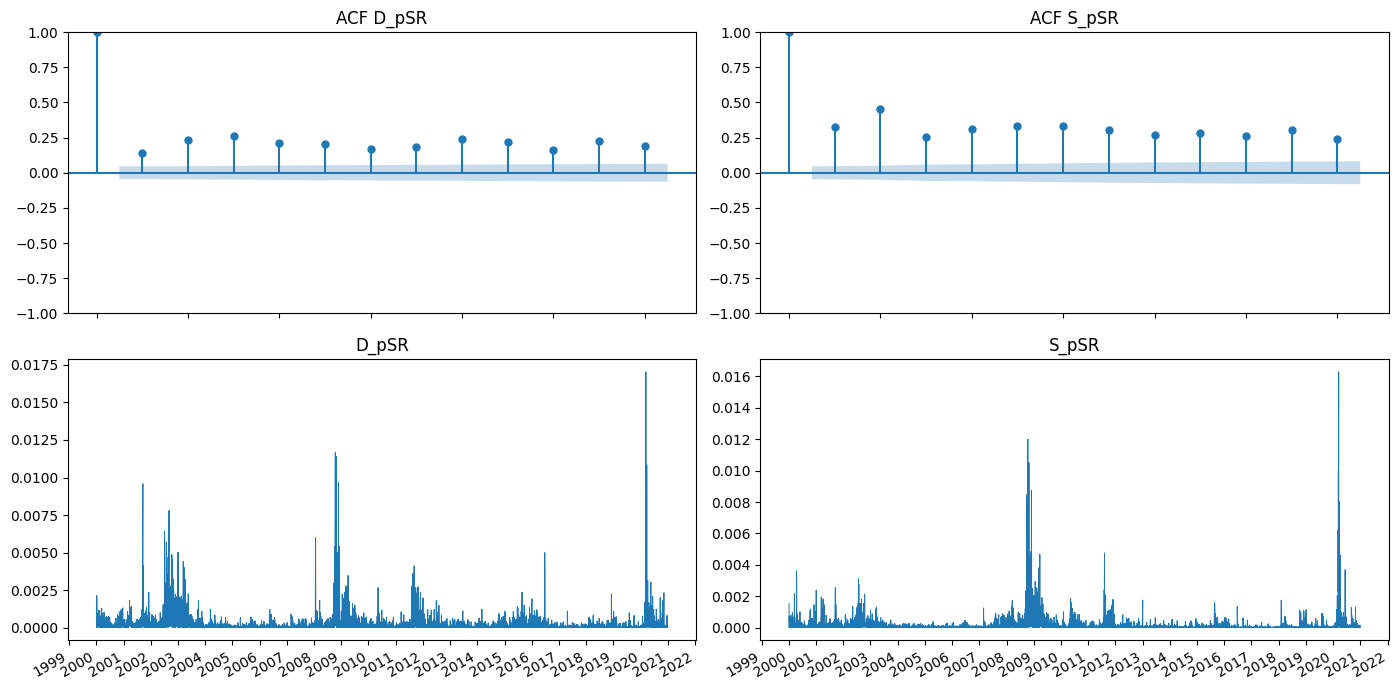

In [717]:
pairs = [
    ("D_logR", "S_logR"),
    ("D_pSR", "S_pSR"),
]

for d_key, s_key in pairs:
    fig, axes = plt.subplots(2, 2, figsize=(14, 7))
    for col, key in enumerate((d_key, s_key)):
        plot_acf(df[key].dropna(), ax=axes[0, col], lags=12, alpha=0.001)
        axes[0, col].set_title(f"ACF {key}")
        axes[1, col].plot(dates, df[key], lw=0.7)
        axes[1, col].set_title(key)
        axes[1, col].xaxis.set_major_locator(mdates.YearLocator(base=1))
        axes[1, col].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

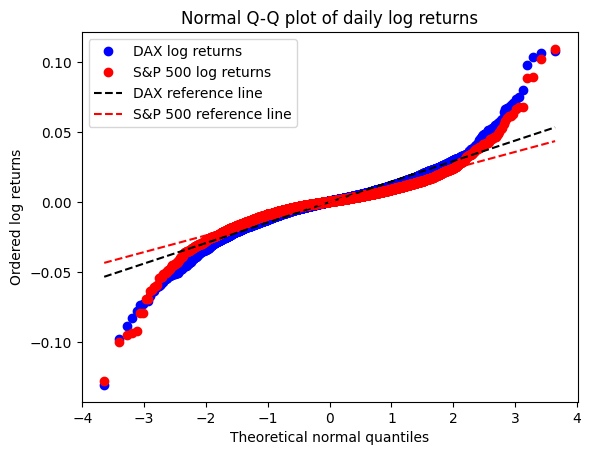

In [718]:
fig, ax = plt.subplots()

(osm1, _), (slope1, intercept1, _) = stats.probplot(
    df["D_logR"].dropna(), plot=ax
)
(osm2, _), (slope2, intercept2, _) = stats.probplot(
    df["S_logR"].dropna(), plot=ax
)

lines = ax.get_lines()
lines[0].set_label("DAX log returns")
lines[1].set_visible(False)
lines[2].set(color="red", label="S&P 500 log returns")
lines[3].set_visible(False)

ax.plot(
    osm1, slope1 * osm1 + intercept1,
    "k--", label="DAX reference line"
)
ax.plot(
    osm2, slope2 * osm2 + intercept2,
    "r--", label="S&P 500 reference line"
)

ax.set(
    xlabel="Theoretical normal quantiles",
    ylabel="Ordered log returns",
    title="Normal Q-Q plot of daily log returns",
)
ax.legend()
plt.show()

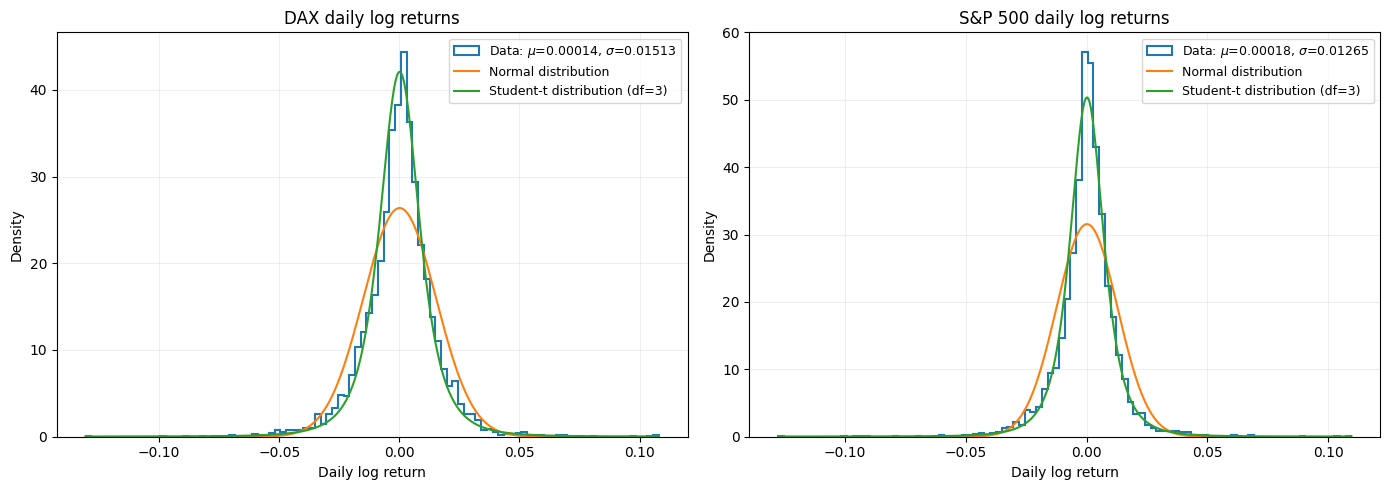

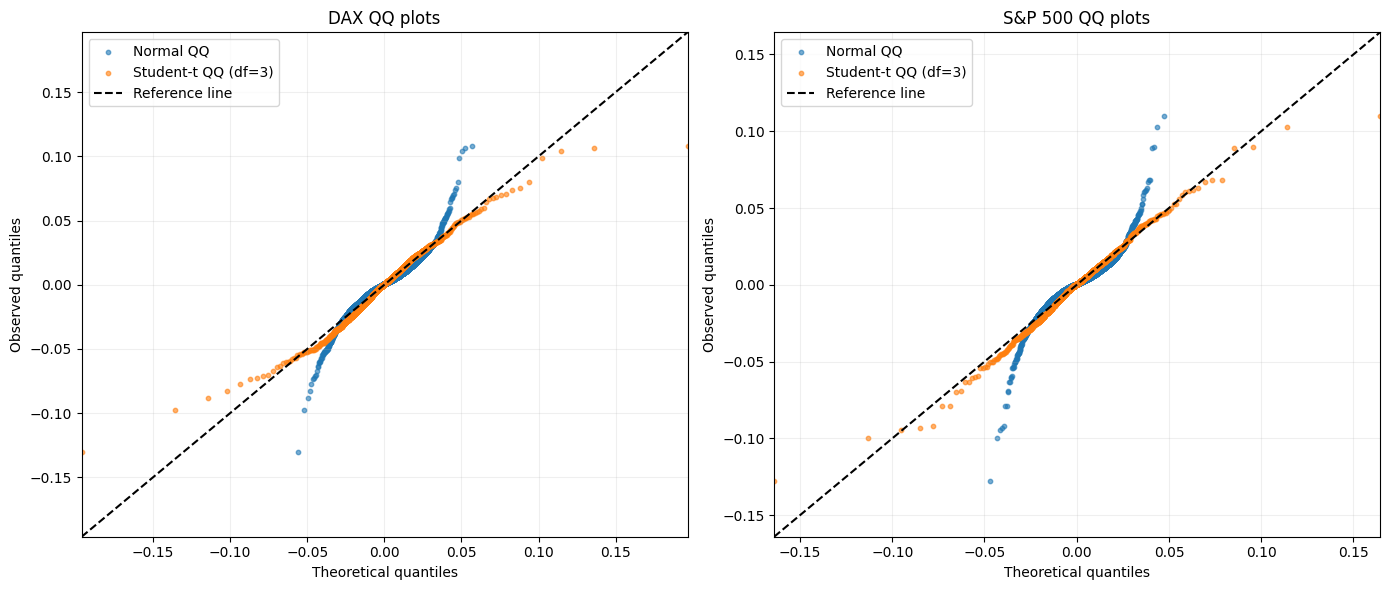

In [719]:
datasets = {
    "DAX": df["D_logR"].dropna(),
    "S&P 500": df["S_logR"].dropna(),
}

t_df = 3

# Histograms with Normal and Student-t distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, data) in zip(axes, datasets.items()):
    mean = data.mean()
    std = data.std(ddof=1)

    # Scale chosen so the t-distribution has standard deviation std
    t_scale = std * np.sqrt((t_df - 2) / t_df)

    x = np.linspace(data.min(), data.max(), 1000)

    ax.hist(
        data,
        bins=100,
        density=True,
        histtype="step",
        linewidth=1.5,
        label=f"Data: $\\mu$={mean:.5f}, $\\sigma$={std:.5f}",
    )

    ax.plot(
        x,
        stats.norm.pdf(x, loc=mean, scale=std),
        label="Normal distribution",
    )

    ax.plot(
        x,
        stats.t.pdf(x, df=t_df, loc=mean, scale=t_scale),
        label="Student-t distribution (df=3)",
    )

    ax.set(
        title=f"{name} daily log returns",
        xlabel="Daily log return",
        ylabel="Density",
    )
    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


# Normal and Student-t QQ plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, data) in zip(axes, datasets.items()):
    observed = np.sort(data.to_numpy())
    probabilities = (np.arange(1, len(observed) + 1) - 0.5) / len(observed)

    mean = data.mean()
    std = data.std(ddof=1)
    t_scale = std * np.sqrt((t_df - 2) / t_df)

    normal_quantiles = stats.norm.ppf(
        probabilities, loc=mean, scale=std
    )
    t_quantiles = stats.t.ppf(
        probabilities, df=t_df, loc=mean, scale=t_scale
    )

    ax.scatter(
        normal_quantiles,
        observed,
        s=10,
        alpha=0.6,
        label="Normal QQ",
    )
    ax.scatter(
        t_quantiles,
        observed,
        s=10,
        alpha=0.6,
        label="Student-t QQ (df=3)",
    )

    limits = [
        min(normal_quantiles.min(), t_quantiles.min(), observed.min()),
        max(normal_quantiles.max(), t_quantiles.max(), observed.max()),
    ]
    ax.plot(limits, limits, "k--", label="Reference line")

    ax.set(
        title=f"{name} QQ plots",
        xlabel="Theoretical quantiles",
        ylabel="Observed quantiles",
        xlim=limits,
        ylim=limits,
    )
    ax.legend()
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

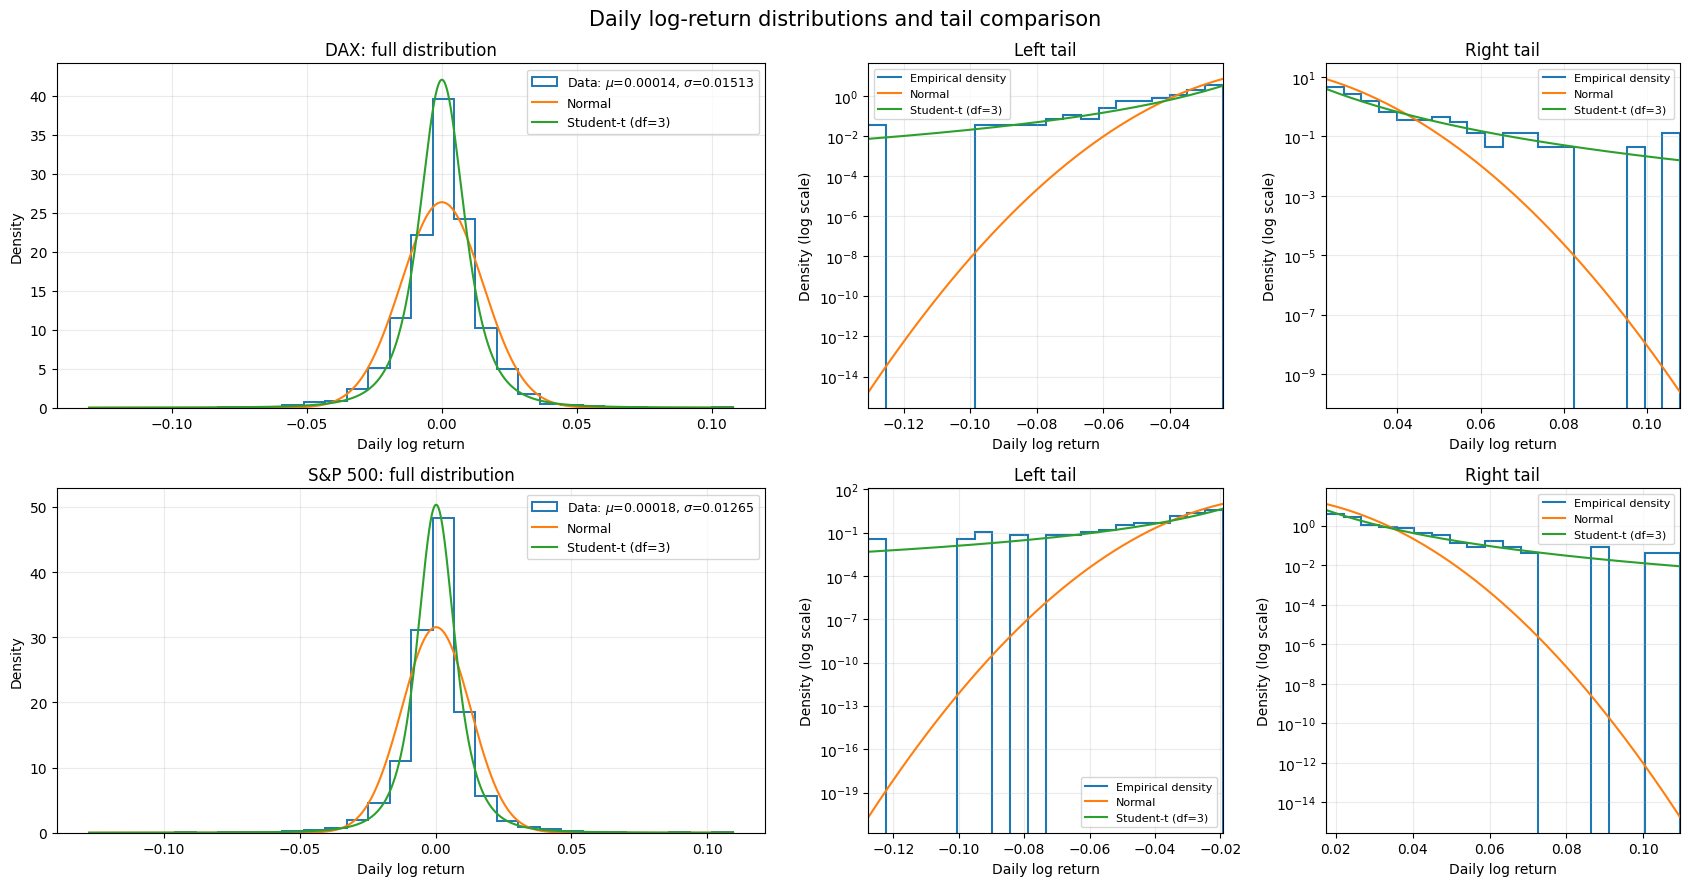

In [720]:
datasets = {
    "DAX": df["D_logR"].dropna(),
    "S&P 500": df["S_logR"].dropna(),
}

t_df = 3

fig, axes = plt.subplots(
    2, 3,
    figsize=(17, 9),
    gridspec_kw={"width_ratios": [2, 1, 1]},
)

for row, (name, data) in enumerate(datasets.items()):
    mean = data.mean()
    std = data.std(ddof=1)
    t_scale = std * np.sqrt((t_df - 2) / t_df)

    x = np.linspace(data.min(), data.max(), 3000)
    normal_pdf = stats.norm.pdf(x, loc=mean, scale=std)
    t_pdf = stats.t.pdf(x, df=t_df, loc=mean, scale=t_scale)

    # Display the full outer 5% on each side
    left_limit = data.quantile(0.05)
    right_limit = data.quantile(0.95)

    full_ax, left_ax, right_ax = axes[row]

    # Full distribution
    full_ax.hist(
        data,
        bins=30,
        density=True,
        histtype="step",
        linewidth=1.4,
        label=f"Data: $\\mu$={mean:.5f}, $\\sigma$={std:.5f}",
    )
    full_ax.plot(x, normal_pdf, label="Normal")
    full_ax.plot(x, t_pdf, label="Student-t (df=3)")

    full_ax.set(
        title=f"{name}: full distribution",
        xlabel="Daily log return",
        ylabel="Density",
    )
    full_ax.legend(fontsize=9)
    full_ax.grid(alpha=0.25)

    # Tail-specific bins, normalized relative to the full dataset
    tail_settings = [
        (left_ax, data.min(), left_limit, "Left tail"),
        (right_ax, right_limit, data.max(), "Right tail"),
    ]

    for ax, lower, upper, title in tail_settings:
        tail_edges = np.linspace(lower, upper, 21)
        counts, edges = np.histogram(data, bins=tail_edges)

        widths = np.diff(edges)
        tail_density = counts / (len(data) * widths)

        ax.stairs(
            tail_density,
            edges,
            linewidth=1.5,
            label="Empirical density",
        )

        mask = (x >= lower) & (x <= upper)
        ax.plot(x[mask], normal_pdf[mask], label="Normal")
        ax.plot(x[mask], t_pdf[mask], label="Student-t (df=3)")

        ax.set(
            title=title,
            xlabel="Daily log return",
            ylabel="Density (log scale)",
            xlim=(lower, upper),
        )
        ax.set_yscale("log")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25)

fig.suptitle(
    "Daily log-return distributions and tail comparison",
    fontsize=15,
)

plt.tight_layout()
plt.show()

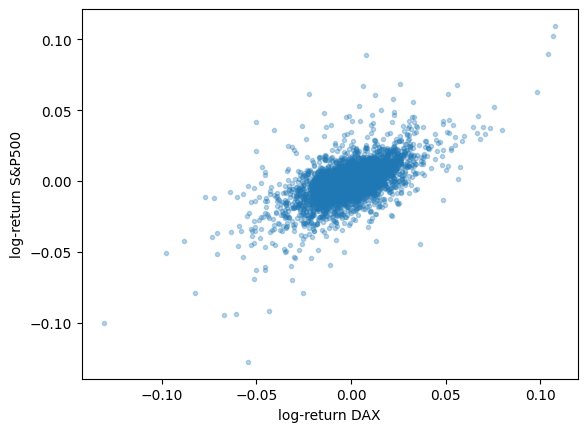

In [721]:
plt.plot(df["D_logR"],df["S_logR"],'.',alpha=0.3
         )


plt.xlabel("log-return DAX")
plt.ylabel("log-return S&P500")
plt.show()


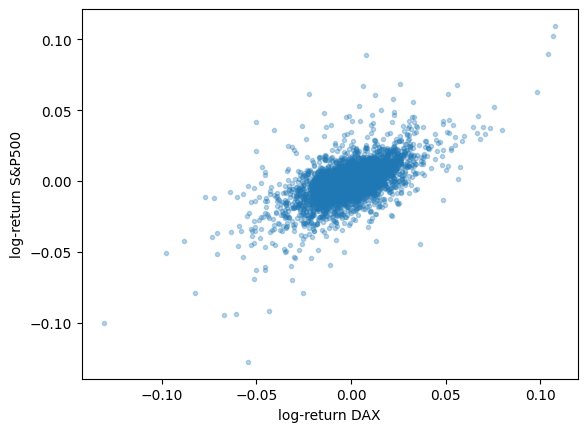

In [722]:
plt.plot(df["D_logR"],df["S_logR"],'.',alpha=0.3
         )


plt.xlabel("log-return DAX")
plt.ylabel("log-return S&P500")
plt.show()


## Cross-correlation: DAX and S&P 500

The lag convention below is $\operatorname{corr}(DAX_t, SP500_{t-k})$. Thus, a **positive** lag means that the S&P 500 leads the DAX, while a **negative** lag means that the DAX leads the S&P 500.

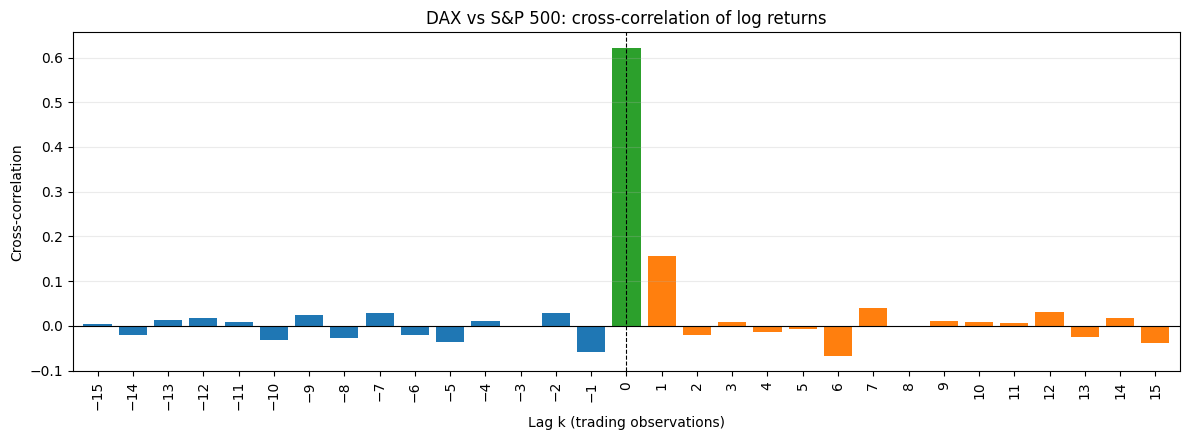

In [723]:
def lagged_cross_correlation(data, dax_col, sp_col, max_lag=15):
    # Keep dates on which both markets have an observed return.
    paired = data[[dax_col, sp_col]].dropna().reset_index(drop=True)
    lags = np.arange(-max_lag, max_lag + 1)
    correlations = [
        paired[dax_col].corr(paired[sp_col].shift(lag))
        for lag in lags
    ]
    return lags, np.asarray(correlations)


def plot_lagged_cross_correlation(data, dax_col, sp_col, title, max_lag=15):
    lags, correlations = lagged_cross_correlation(data, dax_col, sp_col, max_lag)

    fig, ax = plt.subplots(figsize=(12, 4.5))
    colors = np.where(lags < 0, "tab:blue",
                      np.where(lags > 0, "tab:orange", "tab:green"))
    ax.bar(lags, correlations, color=colors, width=0.8)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    tick_step = 1 if max_lag <= 20 else max(1, max_lag // 10)
    ticks = np.arange(-max_lag, max_lag + 1, tick_step)
    ax.set(xticks=ticks, xlim=(-max_lag - 0.7, max_lag + 0.7), xlabel="Lag k (trading observations)",
           ylabel="Cross-correlation", title=title)
    ax.tick_params(axis="x", labelrotation=90)
    ax.grid(axis="y", alpha=0.25)
    fig.tight_layout()
    plt.show()


plot_lagged_cross_correlation(
    df, "D_logR", "S_logR",
    "DAX vs S&P 500: cross-correlation of log returns",
)


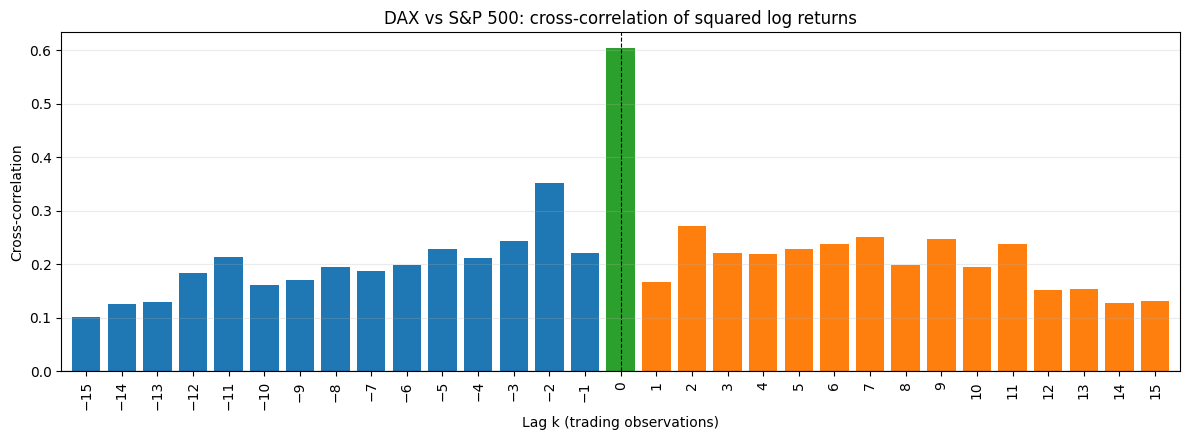

In [724]:
plot_lagged_cross_correlation(
    df, "D_pSR", "S_pSR",
    "DAX vs S&P 500: cross-correlation of squared log returns",
)


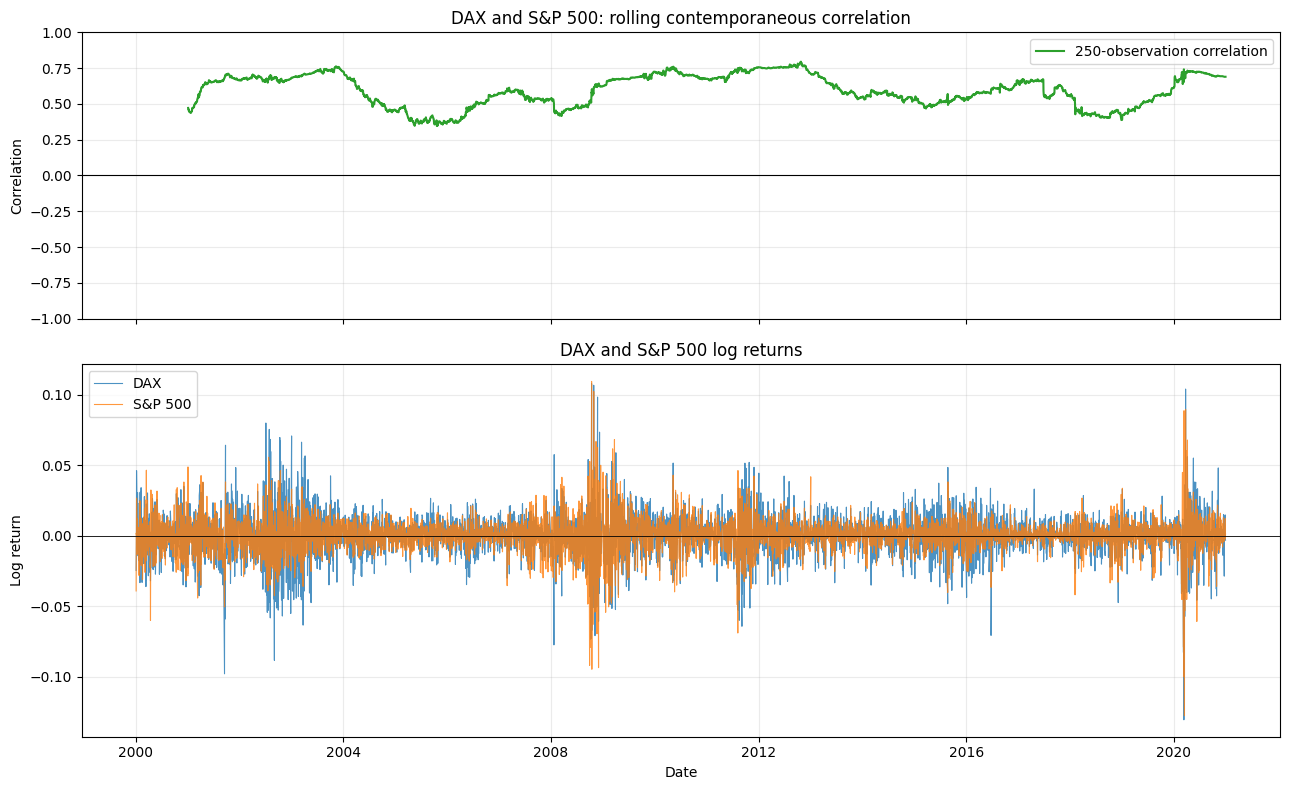

In [725]:
# Rolling lag-0 (contemporaneous) correlation of returns.
rolling_window = 250
contemporaneous = (
    df[["Date", "D_logR", "S_logR"]]
    .dropna()
    .sort_values("Date")
    .set_index("Date")
)
rolling_corr = contemporaneous["D_logR"].rolling(rolling_window).corr(
    contemporaneous["S_logR"]
)
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1.3]})

axes[0].plot(rolling_corr.index, rolling_corr,
             label="250-observation correlation", color="tab:green", linewidth=1.5)
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set(ylim=(-1, 1), ylabel="Correlation",
            title="DAX and S&P 500: rolling contemporaneous correlation")
axes[0].legend()
axes[0].grid(alpha=0.25)


axes[1].plot(contemporaneous.index, contemporaneous["D_logR"],
             label="DAX", color="tab:blue", linewidth=0.8, alpha=0.8)
axes[1].plot(contemporaneous.index, contemporaneous["S_logR"],
             label="S&P 500", color="tab:orange", linewidth=0.8, alpha=0.8)
axes[1].axhline(0, color="black", linewidth=0.6)
axes[1].set(xlabel="Date", ylabel="Log return",
            title="DAX and S&P 500 log returns")
axes[1].legend()
axes[1].grid(alpha=0.25)
fig.tight_layout()
plt.show()


In [726]:
print(np.mean(df["D_logR"].dropna()))
print(np.mean(df["S_logR"].dropna()))
print(np.std(df["D_logR"].dropna(),ddof=1))
print(np.std(df["S_logR"].dropna(),ddof=1))

0.00013655124319704378
0.00018135911979562044
0.015131498755888515
0.012646184841071644


In [727]:
x = np.log(GDAXI_dta[" Close"]).diff(1)
print(np.mean(x),np.std(x,ddof=1))


y = np.log(GSPC_dta[" Close"]).diff(1)

print(np.mean(y),np.std(y,ddof=1))



0.00013306635502387845 0.014908239478841902
0.00017948440395181706 0.012552419077231753


0.5 0.28867513459481287


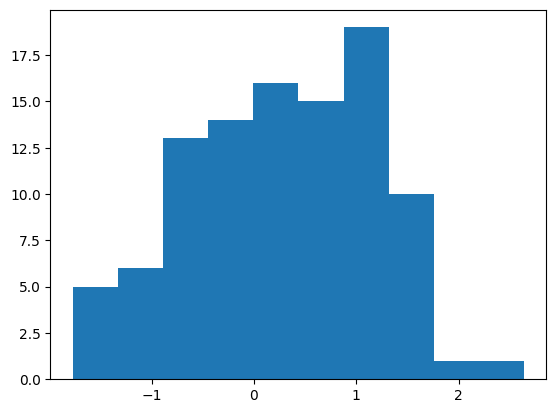

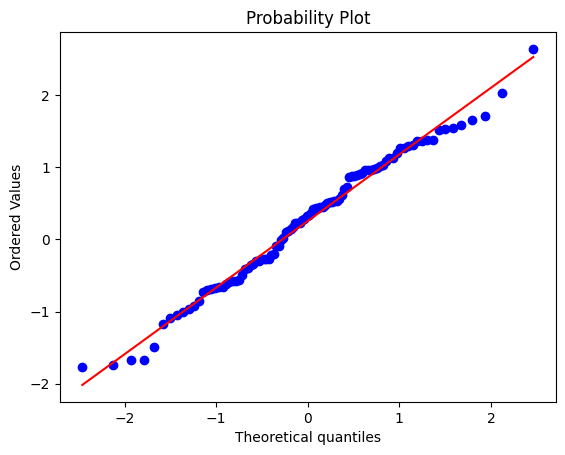

In [728]:
n = 1_00; a=0; b=1
X = np.random.uniform(a,b,size=(n,n))
mu = 0.5*(b-a)
sd = np.sqrt(1/12 *(b-a)**2)
m = np.mean(X,axis=0)

print(mu,sd)
Y = (m-mu)/(sd/np.sqrt(n))

plt.hist(Y)
plt.show()

stats.probplot(Y,plot=plt)
plt.show()

In [729]:
def H_xi(x,xi):
    xx = x[1 + xi*x > 0]

    if xi==0:
        return xx,np.exp(-np.exp(-xx))
    else:
        return xx,np.exp(-(1+xi*xx)**(-1/xi))
    
def h_xi(x,xi):
    xx = x[1 + xi*x > 0]

    if xi==0:
        return xx,np.exp(-xx)*np.exp(-np.exp(-xx))
    else:
        return xx,(1+xi*xx)**(-(1/xi+1))*np.exp(-(1+xi*xx)**(-(1/xi)))

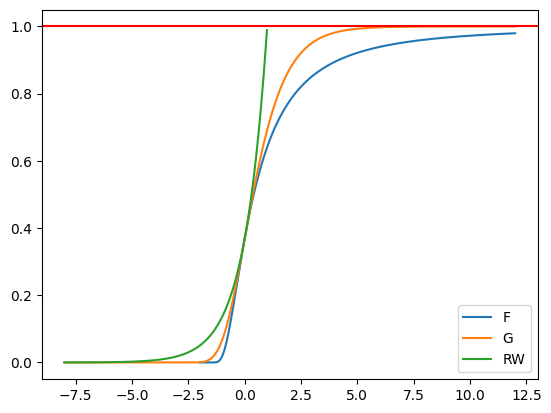

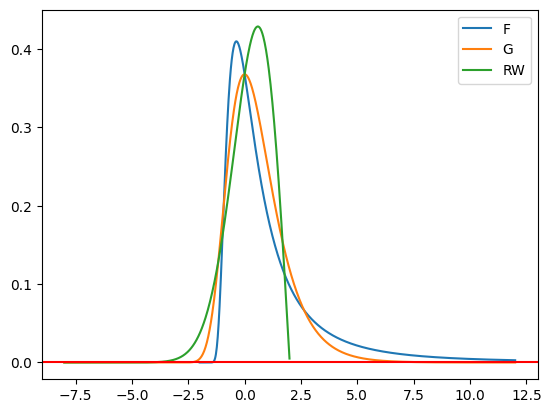

In [730]:
x = np.linspace(-5,5,1000)
mu = -1; sigma=0.5
x = (x-mu)/(sigma)

plt.plot(*H_xi(x,0.5),label="F") # Fréchet
plt.plot(*H_xi(x,0),label="G") # Gumbel
plt.plot(*H_xi(x,-1),label="RW") # Reverse Weibull
plt.axhline(y=1,color="red")
plt.legend()
plt.show()


plt.plot(*h_xi(x,0.5),label="F") # Fréchet
plt.plot(*h_xi(x,0),label="G") # Gumbel
plt.plot(*h_xi(x,-0.5),label="RW") # Reverse Weibull
plt.axhline(y=0,color="red")
plt.legend()
plt.show()

52


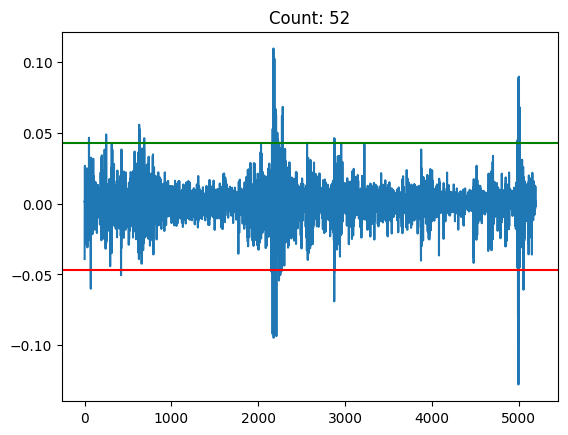

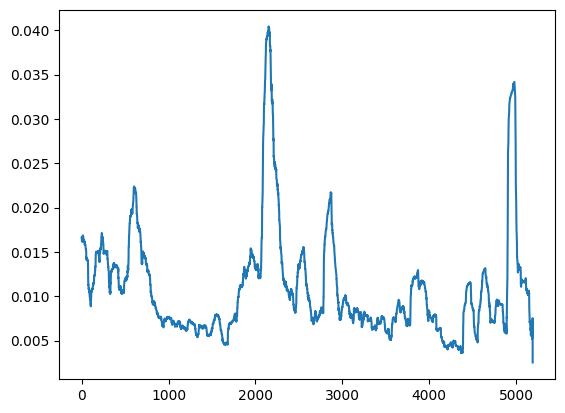

In [731]:
c = 0
qu = np.quantile(df["S_logR"].dropna(),q=0.995)
qd = np.quantile(df["S_logR"].dropna(),q=0.005)

for i in range(len(df["S_logR"])):
    if df["S_logR"][i] > qu:
        c+=1
    if df["S_logR"][i] < qd:
        c+=1
print(c)

plt.plot(df["S_logR"])
plt.axhline(qu,color="green")
plt.axhline(qd,color="red")
plt.title(f"Count: {c}")

plt.show()

s = []
for i in range(len(df["S_logR"])):
    
    s.append(np.std(df["S_logR"][i:90+i],ddof=1))

plt.plot(s)
plt.show()

In [732]:
from scipy.stats import genpareto

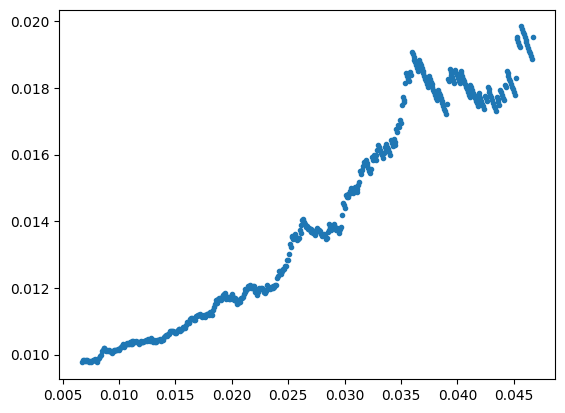

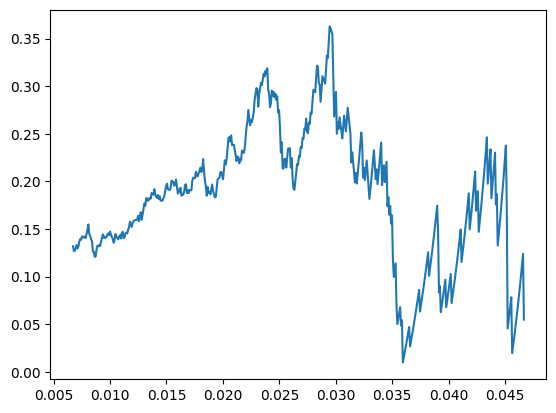

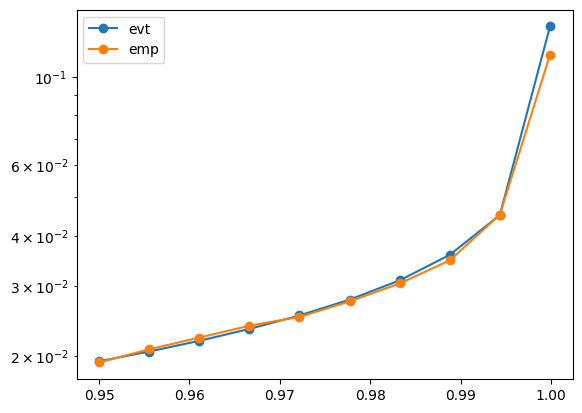

In [733]:
L = -df["S_logR"].dropna()
def e_v(L,v):
    e=[]
    for i in v:
        e.append(sum(L[L>i]-i)/len(L[L>i]))

    return e

v = np.linspace(np.quantile(L,q=0.8),np.quantile(L,q=0.995),num=500)
plt.plot(v,e_v(L,v),'.')
plt.show()

xi_hat = []
for i in v:
    Lu = L[L>i]-i
    xi, _, beta = genpareto.fit(Lu, floc=0)
    xi_hat.append(xi)



plt.plot(v,xi_hat)
plt.show()

u = 0.015
ex = L[L>u]-u
xi, _, beta = genpareto.fit(ex, floc=0)
Nu = len(ex)
q_grid = np.linspace(0.95,0.9999,10)
var_evt = []
var_emp = []
for q in q_grid:
    varEVT_q = u+beta/xi *(((1-q)/(Nu/len(L)))**(-xi)-1)
    var_q = np.quantile(L,q)
    var_evt.append(varEVT_q)
    var_emp.append(var_q)

plt.plot(q_grid,var_evt,'-o',label="evt")
plt.plot(q_grid,var_emp,'-o',label="emp")
plt.yscale("log")
plt.legend()

plt.show()

In [734]:
import arch

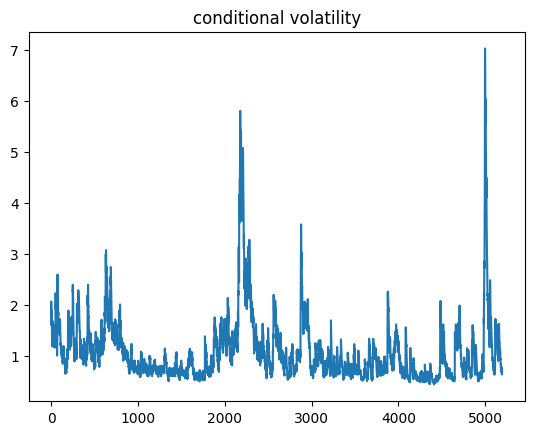

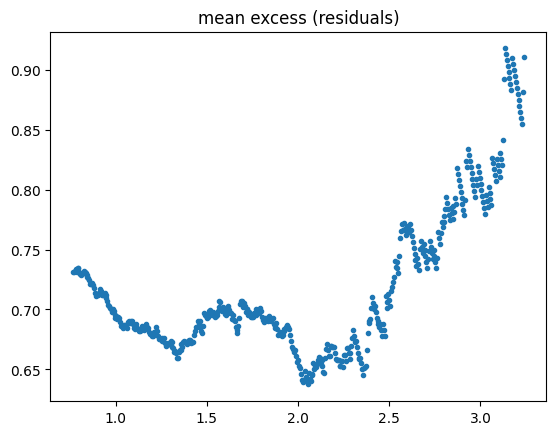

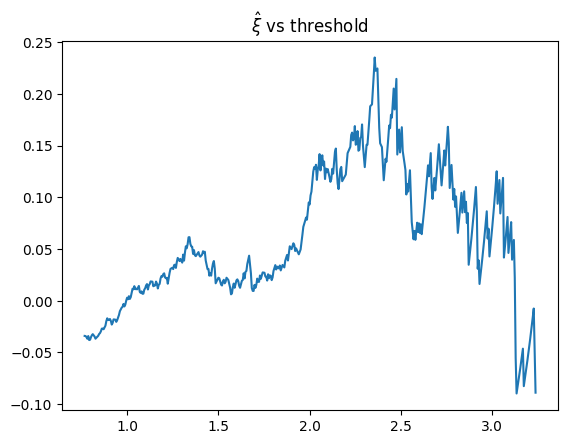

u=2.75  Nu=58  xi=0.147  beta=0.636


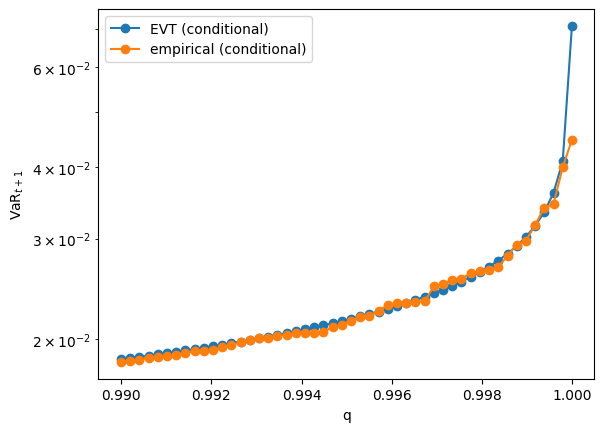

In [797]:
import numpy as np, matplotlib.pyplot as plt, arch
from scipy.stats import genpareto

# --- GARCH on raw returns (x100 for numerical stability), let arch fit the mean ---
r = L.dropna() * 100                          # L = raw returns (e.g. -df["S_logR"])
model = arch.arch_model(r, mean='Constant', vol='GARCH', p=1, q=1)
res = model.fit(disp="off")

mu    = res.params['mu']                       # fitted mean (on x100 scale)
z     = res.std_resid.dropna()                 # standardized residuals
sig   = np.sqrt(res.forecast(horizon=1).variance.iloc[-1, 0])   # sigma_{t+1}, x100 scale

plt.plot(res.conditional_volatility); plt.title('conditional volatility'); plt.show()

# --- mean excess plot on residuals ---
def e_v(L, v):
    return [ (L[L>i]-i).sum() / len(L[L>i]) for i in v ]

v = np.linspace(np.quantile(z, 0.80), np.quantile(z, 0.995), 500)
plt.plot(v, e_v(z, v), '.'); plt.title('mean excess (residuals)'); plt.show()

# --- shape stability ---
xi_hat = [ genpareto.fit(z[z>i]-i, floc=0)[0] for i in v ]
plt.plot(v, xi_hat); plt.title(r'$\hat\xi$ vs threshold'); plt.show()

# --- POT fit on residuals ---
u  = 2.75
ex = z[z>u] - u
xi, _, beta = genpareto.fit(ex, floc=0)
Nu, n = len(ex), len(z)
print(f"u={u}  Nu={Nu}  xi={xi:.3f}  beta={beta:.3f}")

# --- conditional VaR: z-quantile then rescale by (mu, sigma_{t+1}); /100 back to return scale ---
q_grid = np.linspace(0.99, 0.99999, 50)
zq_evt = u + beta/xi * (((1-q_grid)/(Nu/n))**(-xi) - 1)     # POT residual quantiles
zq_emp = np.quantile(z, q_grid)                            # empirical residual quantiles

var_evt = (mu + sig*zq_evt) / 100                          # back to raw-return units
var_emp = (mu + sig*zq_emp) / 100

plt.plot(q_grid, var_evt, '-o', label="EVT (conditional)")
plt.plot(q_grid, var_emp, '-o', label="empirical (conditional)")
plt.yscale("log"); plt.xlabel('q'); plt.ylabel(r'$\mathrm{VaR}_{t+1}$')
plt.legend(); plt.show()

In [798]:
n_eff = len(z)
q_max_emp = 1 - 1/n_eff      # beyond this, empirical is pinned to the max
print(q_max_emp)

0.9998074330829964


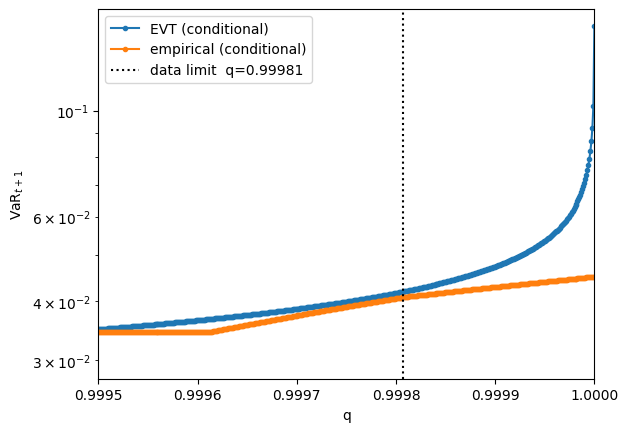

In [805]:
# --- push q past the data boundary so empirical breaks down ---
q_grid = np.linspace(0.999, 0.9999999, 1000)
zq_evt = u + beta/xi * (((1-q_grid)/(Nu/n))**(-xi) - 1)
zq_emp = np.quantile(z, q_grid)

var_evt = (mu + sig*zq_evt) / 100
var_emp = (mu + sig*zq_emp) / 100

q_star = 1 - 1/n                              # empirical is pinned to the max beyond this

plt.plot(q_grid, var_evt, '-o', ms=3, label="EVT (conditional)")
plt.plot(q_grid, var_emp, '-o', ms=3, label="empirical (conditional)")
plt.xlim(0.9995,1)
plt.axvline(q_star, color='k', ls=':', label=f'data limit  q={q_star:.5f}')
plt.yscale("log"); plt.xlabel('q'); plt.ylabel(r'$\mathrm{VaR}_{t+1}$')
plt.legend(); plt.show()

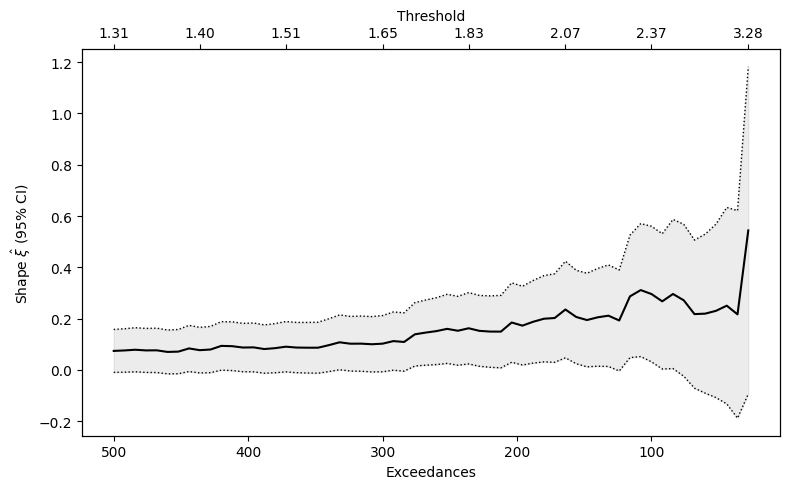

In [ ]:
k = 0.999999
i = np.searchsorted(q_grid, k)
print(f"q={k}  EVT={var_evt[i]:.5f}  emp={var_emp[i]:.5f}")
print(f"horizon: 1/(1-k) = {1/(1-k):.0f} days ≈ {1/(1-k)/252:.1f} yr")
p = np.random.normal(np.mean(r),np.std(r,ddof=1),size=10000)
print(np.quantile(p,k)/252)

q=0.999999  EVT=0.15052  emp=0.04494
horizon: 1/(1-k) = 1000000 days ≈ 3968.3 yr


In [825]:
"""
Conditional EVT (POT) VaR + Expected Shortfall pipeline.
GJR-GARCH-t filter -> POT on standardized residuals -> conditional VaR & ES.
Calibration: return period the worst observed loss implies under BOTH
VaR and ES, for EVT and Gaussian, checked against sample length.
"""
import numpy as np, matplotlib.pyplot as plt, arch, pandas as pd
from scipy.stats import genpareto, norm
from scipy.optimize import brentq

# ------------------------------------------------------------------
# 0. DATA
# ------------------------------------------------------------------
try:
    L_raw = -df["S_logR"].dropna()
except NameError:
    rng = np.random.default_rng(0)
    L_raw = pd.Series(-np.exp(-4)*rng.standard_t(4, 5000))

# ------------------------------------------------------------------
# 1. GJR-GARCH(1,1)-t filter  (o=1 asymmetry, dist='t' heavy innovations)
# ------------------------------------------------------------------
r   = L_raw * 100
res = arch.arch_model(r, mean='Constant', vol='GARCH', p=1, o=1, q=1, dist='t').fit(disp="off")
mu  = res.params['mu']
z   = res.std_resid.dropna()
sig = np.sqrt(res.forecast(horizon=1).variance.iloc[-1,0])
n   = len(z)
gamma = res.params.get('gamma[1]', np.nan)
print(f"[GJR]  gamma={gamma:.3f}  (positive => downside raises vol more; asymmetry real)")

# ------------------------------------------------------------------
# 2. THRESHOLD DIAGNOSTICS
# ------------------------------------------------------------------
def e_v(x, v):
    return np.array([ (x[x>i]-i).sum()/max((x>i).sum(),1) for i in v ])

v = np.linspace(np.quantile(z,0.80), np.quantile(z,0.995), 300)
xi_path = np.array([ genpareto.fit(z[z>i]-i, floc=0)[0] for i in v ])
fig, ax = plt.subplots(1,2, figsize=(11,4))
ax[0].plot(v, e_v(z,v), '.', ms=3); ax[0].set(title='mean excess (residuals)', xlabel='v', ylabel='e(v)')
ax[1].plot(v, xi_path); ax[1].set(title=r'shape $\hat\xi$ vs threshold', xlabel='u', ylabel=r'$\hat\xi$')
plt.tight_layout();  plt.close()

# ------------------------------------------------------------------
# 3. POT FIT
# ------------------------------------------------------------------
u  = 2.5
ex = z[z>u] - u
xi, _, beta = genpareto.fit(ex, floc=0)
Nu = len(ex)
if xi >= 1:
    print(f"[WARN] xi={xi:.3f} >= 1 : mean/ES infinite, tail estimate unreliable")
print(f"[POT]  u={u}  Nu={Nu}  xi={xi:.3f}  beta={beta:.3f}")

def z_pot(q): return u + beta/xi * (((1-q)/(Nu/n))**(-xi) - 1)      # VaR (residual space)
def z_es(q):  return z_pot(q)/(1-xi) + (beta - xi*u)/(1-xi)         # ES  (residual space)

# ------------------------------------------------------------------
# 4. CONDITIONAL VaR & ES CURVES vs empirical
# ------------------------------------------------------------------
q_grid  = np.linspace(0.99, 0.99999, 200)
var_evt = (mu + sig*z_pot(q_grid)) / 100
es_evt  = (mu + sig*z_es (q_grid)) / 100
var_emp = (mu + sig*np.quantile(z, q_grid)) / 100
q_star  = 1 - 1/n
plt.figure(figsize=(8,5))
plt.plot(q_grid, es_evt , '-', label="ES  (EVT)")
plt.plot(q_grid, var_evt, '-', label="VaR (EVT)")
plt.plot(q_grid, var_emp, '-', label="VaR (empirical)")
plt.axvline(q_star, color='k', ls=':', label=f'data limit q={q_star:.5f}')
plt.yscale("log"); plt.xlabel('q'); plt.ylabel(r'loss level ($t{+}1$)')
plt.legend(); plt.title('Conditional VaR vs ES')
plt.tight_layout(); plt.close()

# ------------------------------------------------------------------
# 5. POINT VaR & ES with horizon
# ------------------------------------------------------------------
for k in (0.999, 0.9999, 0.99999):
    ev = (mu + sig*z_pot(k))/100
    es = (mu + sig*z_es (k))/100
    print(f"[q={k}]  VaR={ev:.4f}  ES={es:.4f}  (ES/VaR={es/ev:.2f})  horizon≈{1/(1-k)/252:,.1f} yr")

# ------------------------------------------------------------------
# 6. CALIBRATION: horizon the WORST OBSERVED loss implies under
#    VaR and ES, for EVT and Gaussian.  (unconditional scale)
# ------------------------------------------------------------------
Y = 252
x_obs, std_raw, mean_raw = L_raw.max(), L_raw.std(ddof=1), L_raw.mean()
z_obs = x_obs/std_raw

# EVT, residual space
P_evt_var = (Nu/n)*(1 + xi*(z_obs-u)/beta)**(-1/xi)                 # VaR = x_obs
zp_t      = z_obs*(1-xi) - (beta - xi*u)                            # ES  = x_obs -> target VaR level
P_evt_es  = (Nu/n)*(1 + xi*(zp_t-u)/beta)**(-1/xi) if zp_t > u else np.nan

# Gaussian, loss space
zg      = (x_obs-mean_raw)/std_raw
P_g_var = norm.sf(zg)                                               # VaR = x_obs
g_es    = lambda q: mean_raw + std_raw*norm.pdf(norm.ppf(q))/(1-q)  # Gaussian ES_q
try:    P_g_es = 1 - brentq(lambda q: g_es(q)-x_obs, 0.5, 1-1e-15)
except Exception: P_g_es = np.nan

yr = lambda P: np.inf if (P is None or np.isnan(P) or P<=0) else 1/P/Y
print("\n[CALIBRATION] return period the observed max implies")
print(f"  observed max loss = {x_obs:.4f}   (z ≈ {z_obs:.2f})   sample = {n/Y:.1f} yr\n")
print(f"  {'':10s}{'VaR-implied':>16s}{'ES-implied':>16s}")
print(f"  {'EVT':10s}{yr(P_evt_var):>13,.1f} yr{yr(P_evt_es):>13,.1f} yr")
print(f"  {'Gaussian':10s}{yr(P_g_var):>13.3e} yr{yr(P_g_es):>13.3e} yr")

[GJR]  gamma=-0.209  (positive => downside raises vol more; asymmetry real)
[POT]  u=2.5  Nu=79  xi=0.301  beta=0.562
[q=0.999]  VaR=0.0263  ES=0.0363  (ES/VaR=1.38)  horizon≈4.0 yr
[q=0.9999]  VaR=0.0495  ES=0.0696  (ES/VaR=1.41)  horizon≈39.7 yr
[q=0.99999]  VaR=0.0961  ES=0.1363  (ES/VaR=1.42)  horizon≈396.8 yr

[CALIBRATION] return period the observed max implies
  observed max loss = 0.1277   (z ≈ 10.09)   sample = 20.6 yr

                 VaR-implied      ES-implied
  EVT                57.0 yr         17.3 yr
  Gaussian      1.566e+21 yr          inf yr


In [807]:

print(np.max(-df["S_logR"]))

0.1276521411564726


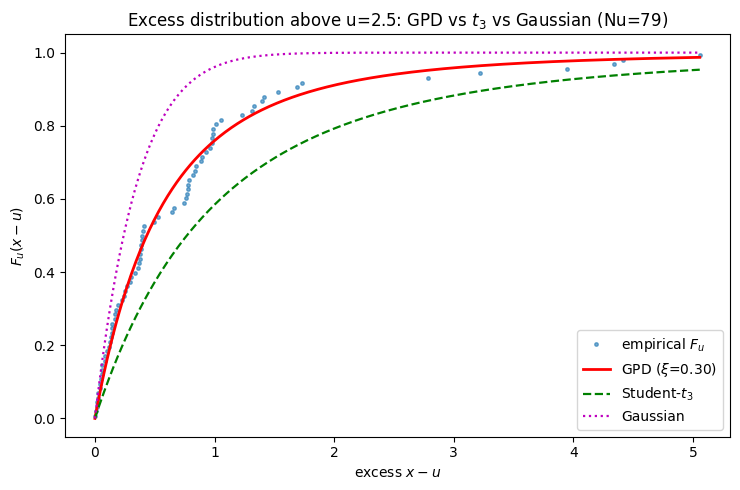

In [827]:
# ------------------------------------------------------------------
# 7b. Excess CDF: GPD vs fixed Student-t3 vs Gaussian
#     model excess CDF:  F_u(y) = (F(u+y)-F(u)) / (1-F(u))
# ------------------------------------------------------------------
from scipy.stats import t as tdist
ex_s = np.sort(z[z>u]-u); ecdf = (np.arange(1,Nu+1)-0.5)/Nu
xx = np.linspace(0, ex_s.max(), 400)
tp, gp = tdist.fit(z, f0=3), norm.fit(z)           # t (df=3 fixed), Gaussian
exc = lambda cdf: (cdf(u+xx)-cdf(u))/(1-cdf(u))

plt.figure(figsize=(7.5,5))
plt.plot(ex_s, ecdf, '.', ms=5, alpha=.6, label=r'empirical $F_u$')
plt.plot(xx, genpareto.cdf(xx, xi,0,beta), 'r-',  lw=2,   label=fr'GPD ($\xi$={xi:.2f})')
plt.plot(xx, exc(lambda x: tdist.cdf(x,*tp)),'g--', lw=1.6, label=r'Student-$t_3$')
plt.plot(xx, exc(lambda x: norm.cdf(x,*gp)), 'm:',  lw=1.6, label='Gaussian')
plt.xlabel(r'excess $x-u$'); plt.ylabel(r'$F_u(x-u)$')
plt.title(f'Excess distribution above u={u}: GPD vs $t_3$ vs Gaussian (Nu={Nu})')
plt.legend(); plt.tight_layout(); plt.show()

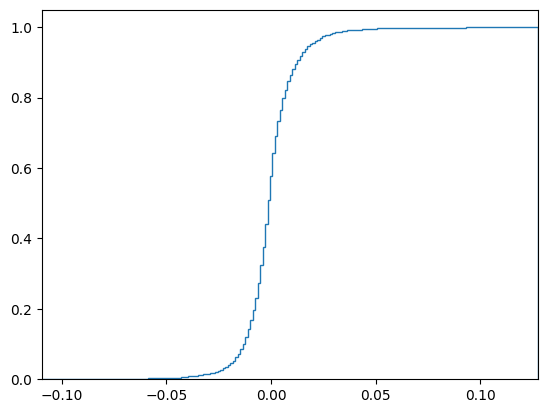

In [ ]:
plt.hist(-df["S_logR"].dropna(),histtype="step",cumulative=True,density=True,bins=200)
plt.xlim((min(-df["S_logR"].dropna()),max(-df["S_logR"].dropna())*0.999))
plt.show()

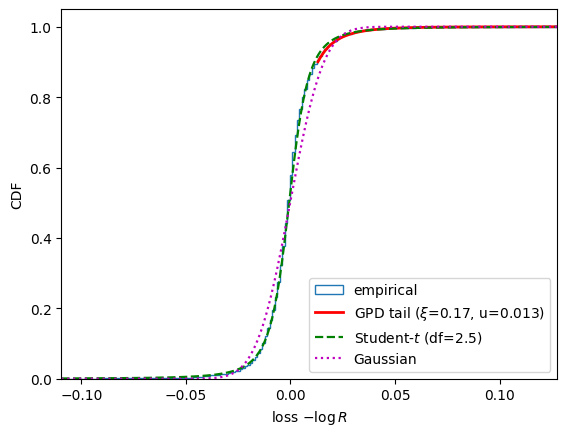

In [835]:
# ------------------------------------------------------------------
# Full loss CDF: empirical + GPD tail + Student-t + Gaussian
# ------------------------------------------------------------------
from scipy.stats import genpareto, t as tdist, norm
L = -df["S_logR"].dropna(); Lv = L.values; n = len(Lv)

u_L = np.quantile(Lv, 0.90)                          # GPD threshold
ex  = Lv[Lv>u_L] - u_L
xi,_,beta = genpareto.fit(ex, floc=0); Nu = len(ex)
tp, gp = tdist.fit(Lv), norm.fit(Lv)                 # t (free df), Gaussian

xx = np.linspace(Lv.min(), Lv.max()*0.999, 600)
with np.errstate(invalid='ignore'):
    F_gpd = 1 - (Nu/n)*(1 + xi*(xx-u_L)/beta)**(-1/xi)   # POT tail CDF, x>=u_L
F_gpd = np.where(xx>=u_L, F_gpd, np.nan)

plt.hist(Lv, histtype="step", cumulative=True, density=True, bins=200, label='empirical')
plt.plot(xx, F_gpd,            'r-',  lw=2,   label=fr'GPD tail ($\xi$={xi:.2f}, u={u_L:.3f})')
plt.plot(xx, tdist.cdf(xx,*tp),'g--', lw=1.6, label=fr'Student-$t$ (df={tp[0]:.1f})')
plt.plot(xx, norm.cdf(xx,*gp), 'm:',  lw=1.6, label='Gaussian')
plt.xlim(Lv.min(), Lv.max()*0.999)
plt.xlabel(r'loss $-\log R$'); plt.ylabel('CDF'); plt.legend(); plt.show()